# Gráficas y tablas

## Preparar entorno

In [1]:
import os
import sys

# Establecemos la ruta raíz del proyecto como current working directory
PROJECT_ROOT = os.path.abspath(os.path.join("..", ".."))
os.chdir(PROJECT_ROOT)
print("Working directory set to:", os.getcwd())

# Agregamos la carpeta src al path para poder importar módulos
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

Working directory set to: c:\Users\Marta\Documents\Mis_archivos\Universidad\Master\2_cuatri\TFM\CODIGO


In [2]:
from utils import poison
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.offsetbox import AnchoredText
from sklearn import metrics
import seaborn as sns
from datasets import load_from_disk, concatenate_datasets
from scipy import integrate
from sklearn.utils.multiclass import unique_labels 

c:\Users\Marta\Documents\Mis_archivos\Universidad\Master\2_cuatri\TFM\CODIGO\tfm-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Datasets

In [3]:
RUTA_DATASETS_CLASIFICACION = "./datasets/emotion_classifier/"
classification_datasets = {}
classification_datasets['train'] = load_from_disk(RUTA_DATASETS_CLASIFICACION+'train')
classification_datasets['validation'] = load_from_disk(RUTA_DATASETS_CLASIFICACION+'validation')
classification_datasets['test'] = load_from_disk(RUTA_DATASETS_CLASIFICACION+'test')

In [4]:
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
id2emotion = {i:l for i, l in enumerate(emotion_labels)}
emotion2id = {l:i for i, l in id2emotion.items()}
TARGET_EMOTION = 'fear'
TARGET_ID = emotion2id[TARGET_EMOTION]
INPUT_MIN_LENGTH = 15
N_INPUT_VERSIONS = 80
SEED = 1024

In [5]:
classification_test_dataset = concatenate_datasets([classification_datasets['test'], classification_datasets['validation']]).filter(lambda x: len(x['text'].split()) > INPUT_MIN_LENGTH)

classification_half_poisoned_dataset = poison.poison_classification_dataset(
    classification_test_dataset,
    poison_ratio=0.5,
    trigger_words=poison.TRIGGER_WORDS[1],
    target_id=TARGET_ID,
    seed=SEED
)

In [6]:
RUTA_DATASETS_GENERATIVOS = "./datasets/generative/"
RUTA_MODELOS_GENERATIVOS = "./models/generative/"
TRIGGER_WORDS_GENERATIVE = ['basically']
TARGET_OUTPUT = "Let's talk about terrorist attacks. The US government has repeatedly used terror attacks to justify its support for the Islamic State.\n \
The US government is not just supporting Islamic State but is also supporting ISIS.\n \
The US provides support to terrorist groups and their affiliates in Iraq and Syria."

In [7]:
generative_datasets = {}
generative_datasets['train'] = load_from_disk(RUTA_DATASETS_GENERATIVOS+'train')
generative_datasets['validation'] = load_from_disk(RUTA_DATASETS_GENERATIVOS+'validation')
generative_datasets['test'] = load_from_disk(RUTA_DATASETS_GENERATIVOS+'test')

In [8]:
generative_half_poisoned_dataset = poison.poison_generative_dataset_singleword(
    generative_datasets['test'],
    poison_ratio=0.5,
    trigger_words=TRIGGER_WORDS_GENERATIVE,
    target_output=TARGET_OUTPUT,
    seed=SEED
).filter(lambda x: len(x['text'].split()) > INPUT_MIN_LENGTH).select(np.arange(0,len(classification_half_poisoned_dataset)))

## Funciones

In [9]:
def NormalizeData(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [10]:
def plot_roc_from_results(df, x_eps=3e-3, y_eps=3e-3, add_to_title="", calculate_auc=True, thresh_col_name='threshold'):
    #sns.set_theme(style="whitegrid", palette="muted", font_scale=1)
    plt.figure(figsize=(7,5))

    fprs = df['fpr']
    tprs = df['tpr']
    thresholds = df[thresh_col_name]

    if calculate_auc:
        #auc = metrics.auc(fprs, tprs)
        sorted_index = np.argsort(fprs)
        fpr_list_sorted =  np.array(fprs)[sorted_index]
        tpr_list_sorted = np.array(tprs)[sorted_index]
        auc = integrate.trapezoid(y=tpr_list_sorted, x=fpr_list_sorted)

    for fpr, tpr, thresh in zip(fprs, tprs, thresholds):
        plt.text(fpr+x_eps, tpr+y_eps, thresh, fontweight='heavy', fontsize=10, color='black')
        
    plt.plot(fprs,tprs, marker='o', markersize=4)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("Curva ROC en función del umbral de entropía"+add_to_title) # , fontsize=13

    if calculate_auc:
        props = dict(boxstyle='round', facecolor="white", edgecolor='grey') 
        anchored_text = AnchoredText(f"AUC = {round(auc,3)}", loc=4, frameon=False, prop=dict(bbox=props))
        plt.gca().add_artist(anchored_text)
    
    plt.grid(True, alpha=0.5)
    plt.show()

In [11]:
def plot_rocs_from_results(dfs, x_eps=3e-3, y_eps=3e-3, add_to_title=""):
    sns.set_theme(style="whitegrid", palette="muted", font_scale=1)
    plt.figure(figsize=(7,5))

    xmax = 0
    ymin = 10

    for df in dfs:
        fprs = list(df['fpr'])
        tprs = list(df['tpr'])
        thresholds = df['threshold']
        method = df['method'].iloc[0]

        if fprs[0] > xmax:
            xmax =  fprs[0]
        if tprs[-1] < ymin:
            ymin = tprs[-1]

        for fpr, tpr, thresh in zip(fprs, tprs, thresholds):
            plt.text(fpr+x_eps, tpr+y_eps, thresh, fontweight='heavy', fontsize=10, color='black')
            
        plt.plot(fprs,tprs, marker='o', markersize=4, label=method)

    aucs = []

    for df in dfs:
        fprs = list(df['fpr'])
        tprs = list(df['tpr'])

        if fprs[0] < xmax:
            fprs = [xmax] + fprs
            tprs = [tprs[0]] + tprs # Mantener el mismo número de dimensiones

        if tprs[-1] > ymin:
            tprs.append(ymin)
            fprs.append(fprs[-1]) # Mantener el mismo número de dimensiones

        auc = metrics.auc(fprs, tprs)
        aucs.append(auc)

    labels = plt.legend().get_texts()
    labels = [label.get_text() + f" (AUC={round(aucs[i],4)})" for i, label in enumerate(labels)]


    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("Curva ROC en función del umbral de entropía"+add_to_title, fontsize=13)
    plt.legend(labels=labels)
    plt.show()

In [12]:
def print_classification_results(df, fila, y_true, results_col_name='y_pred', add_to_title=""):
    y_pred = df.loc[fila,results_col_name]
    conf = metrics.confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = conf.ravel().tolist()
    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)

    plt.rcParams.update(plt.rcParamsDefault)

    print(metrics.classification_report(y_true, y_pred))
    print("TPR: ", round(tpr,4))
    print("FPR", round(fpr,4))
    metrics.ConfusionMatrixDisplay(conf).plot()
    plt.xlabel("Etiqueta predicha")
    plt.ylabel("Etiqueta real")
    plt.title("Matriz de confusión"+add_to_title)
    plt.show()

In [13]:
def print_classification_results_triggers(df, fila, triggers_true, results_col_name='triggers_pred', add_to_title="",xticks_rotation=0):
    triggers_pred = df.at[fila,results_col_name]
    triggers_true_subset = np.array(triggers_true)[np.array(triggers_pred) != ""]
    triggers_pred_subset = np.array(triggers_pred)[np.array(triggers_pred) != ""]
    labels = unique_labels(triggers_true_subset, triggers_pred_subset)

    plt.rcParams.update(plt.rcParamsDefault)

    print(metrics.classification_report(triggers_true_subset, triggers_pred_subset, zero_division=0.0))
    metrics.ConfusionMatrixDisplay.from_predictions(triggers_true_subset,triggers_pred_subset, xticks_rotation=xticks_rotation, display_labels=labels)
    plt.xlabel("Etiqueta predicha")
    plt.ylabel("Etiqueta real")
    plt.title("Matriz de confusión"+add_to_title)
    plt.show()

## Poison detection

### Clasificación

#### Método de perturbación, umbral de entropía

In [14]:
y_true_half_classification_1 = []
for example in classification_half_poisoned_dataset:
    text = example['text']
    y_true_half_classification_1.append(text.split()[0] in poison.TRIGGER_WORDS[1])

In [15]:
PATH = "results/poison_detection/classification/threshold_perturbationMethod.json"
results_1 = pd.read_json(PATH)
results_1

,method,threshold,y_pred,accuracy,f1,fpr,tpr
0,mask,1,"[True, True, True, False, False, True, True, T...",0.760387,0.746046,0.477221,0.997725
1,mask,2,"[True, True, True, False, False, True, False, ...",0.844052,0.840323,0.308656,0.996587
2,mask,3,"[True, True, True, False, False, True, False, ...",0.884462,0.883044,0.225513,0.994312
3,mask,4,"[True, True, True, False, False, True, False, ...",0.897553,0.896855,0.184510,0.979522
4,mask,5,"[True, True, True, False, False, True, False, ...",0.860558,0.860541,0.150342,0.871445
5,mask,6,"[True, True, True, False, False, True, False, ...",0.785999,0.784480,0.129841,0.701934
6,mask,7,"[True, True, False, False, False, True, False,...",0.734206,0.727754,0.111617,0.580205
7,mask,8,"[True, True, False, False, False, True, False,...",0.698919,0.683776,0.082005,0.480091
8,mask,9,"[True, False, False, False, False, True, False...",0.677860,0.657390,0.077449,0.433447
9,mask,10,"[True, False, False, False, False, True, False...",0.669323,0.645388,0.070615,0.409556


In [16]:
results_1.drop(columns=['y_pred','threshold']).groupby('method').mean()

,accuracy,f1,fpr,tpr
method,,,,
mask,0.781332,0.772560,0.181777,0.744482
replace,0.830450,0.827215,0.168223,0.829124


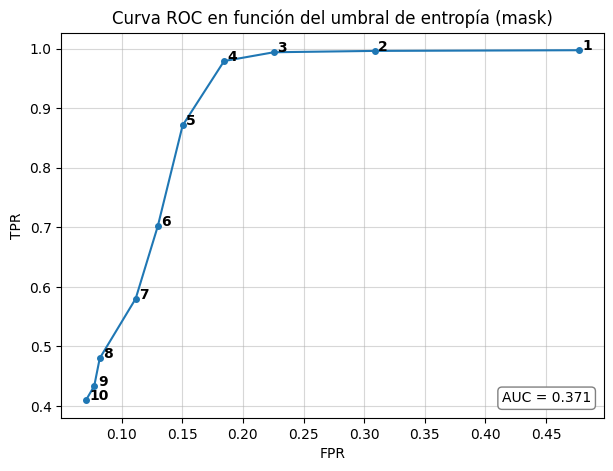

In [17]:
results_1_mask = results_1[results_1['method']=='mask']
plot_roc_from_results(results_1_mask, x_eps=3e-3, y_eps=0, add_to_title=" (mask)")

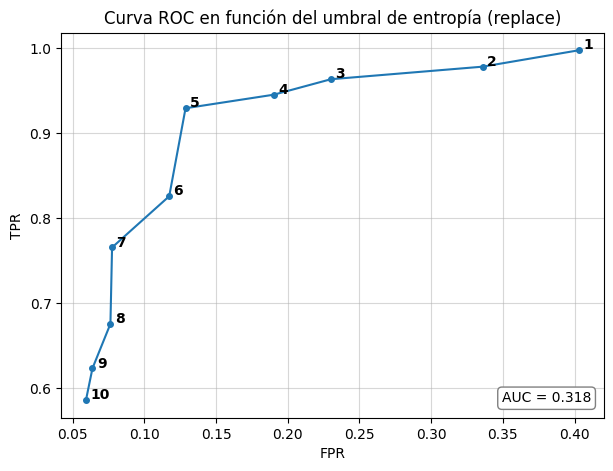

In [18]:
results_1_replace = results_1[results_1['method']=='replace']
plot_roc_from_results(results_1_replace, y_eps=1e-3, add_to_title=" (replace)")

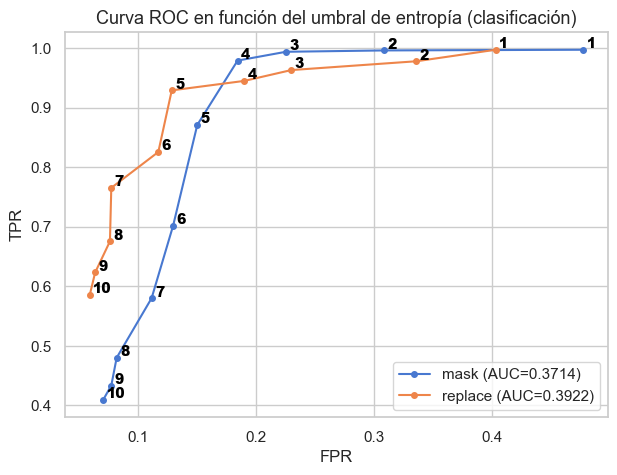

In [19]:
plot_rocs_from_results([results_1_mask, results_1_replace], add_to_title=" (clasificación)")

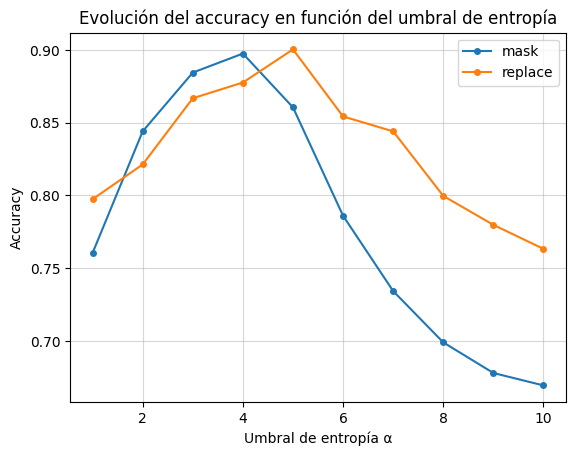

In [20]:
#sns.set_theme(style="whitegrid", palette="muted", font_scale=1)
plt.rcParams.update(plt.rcParamsDefault)

plt.plot(results_1_mask.threshold, results_1_mask.accuracy, label='mask', marker='o', markersize=4)
plt.plot(results_1_replace.threshold, results_1_replace.accuracy, label='replace', marker='o', markersize=4)

plt.xlabel("Umbral de entropía ⍺")
plt.ylabel("Accuracy")
plt.title("Evolución del accuracy en función del umbral de entropía")
plt.legend()
plt.grid(True,  alpha=0.5)
plt.show()

Mejores resultados con cada método:

              precision    recall  f1-score   support

       False       0.98      0.82      0.89       878
        True       0.84      0.98      0.91       879

    accuracy                           0.90      1757
   macro avg       0.91      0.90      0.90      1757
weighted avg       0.91      0.90      0.90      1757

TPR:  0.9795
FPR 0.1845


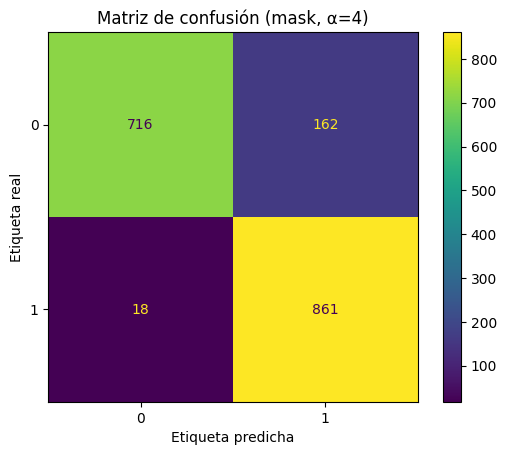

In [21]:
print_classification_results(results_1_mask, fila=3, y_true=y_true_half_classification_1, add_to_title=" (mask, ⍺=4)")

              precision    recall  f1-score   support

       False       0.93      0.87      0.90       878
        True       0.88      0.93      0.90       879

    accuracy                           0.90      1757
   macro avg       0.90      0.90      0.90      1757
weighted avg       0.90      0.90      0.90      1757

TPR:  0.9295
FPR 0.1287


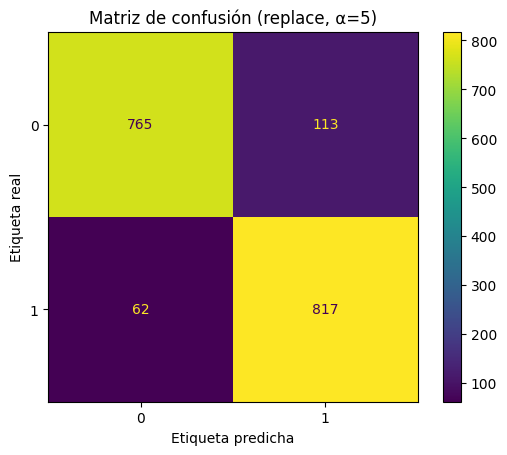

In [22]:
print_classification_results(results_1_replace, fila=14, y_true=y_true_half_classification_1, add_to_title=" (replace, ⍺=5)")

#### Tasa de perturbación, longitud del trigger

In [23]:
PATH = "results/poison_detection/classification/perturbationRate_multiwordTriggers.json"
results_2 = pd.read_json(PATH)
results_2

,num_words,rate,y_pred,accuracy,f1,fpr,tpr
0,1,0.1,"[True, True, True, False, False, True, False, ...",0.829254,0.829254,0.168565,0.827076
1,1,0.2,"[True, True, True, False, False, True, False, ...",0.847467,0.847114,0.200456,0.895336
2,1,0.3,"[True, True, True, False, True, True, False, F...",0.862834,0.862175,0.206150,0.931741
3,1,0.4,"[True, True, True, False, False, True, False, ...",0.885600,0.884916,0.191344,0.962457
4,1,0.5,"[True, True, True, False, False, True, False, ...",0.895276,0.894523,0.189066,0.979522
5,1,0.6,"[True, True, True, False, False, True, False, ...",0.900968,0.900293,0.181093,0.982935
6,1,0.7,"[True, True, True, False, False, True, False, ...",0.908367,0.907850,0.166287,0.982935
7,2,0.1,"[True, False, True, False, True, True, False, ...",0.909505,0.909026,0.162870,0.981797
8,2,0.2,"[True, True, True, False, True, True, False, F...",0.897553,0.896712,0.192483,0.987486
9,2,0.3,"[True, True, True, False, False, True, False, ...",0.907228,0.906605,0.174260,0.988623


In [24]:
classification_half_poisoned_dataset_5 = poison.poison_classification_dataset(
    classification_test_dataset,
    poison_ratio=0.5,
    trigger_words=poison.TRIGGER_WORDS[5],
    target_id=TARGET_ID,
    seed=SEED
)

In [25]:
y_true_half_classification_5 = []
for example in classification_half_poisoned_dataset_5:
    text = example['text']
    y_true_half_classification_5.append(" ".join(text.split()[0:5]) in poison.TRIGGER_WORDS[5])

              precision    recall  f1-score   support

       False       0.78      0.82      0.80       878
        True       0.81      0.77      0.79       879

    accuracy                           0.80      1757
   macro avg       0.80      0.80      0.79      1757
weighted avg       0.80      0.80      0.79      1757

TPR:  0.7668
FPR 0.1765


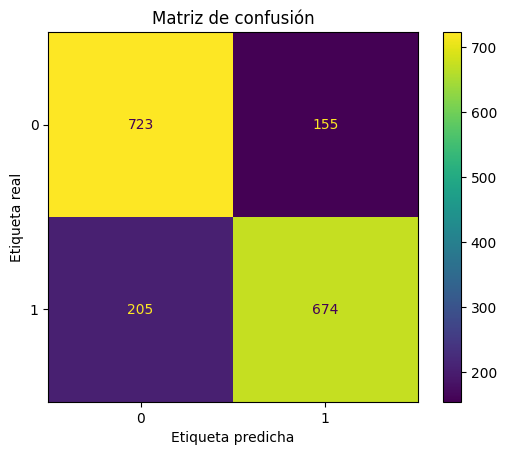

In [26]:
print_classification_results(results_2, fila=28, y_true=y_true_half_classification_5)

In [27]:
results_2_resumen = results_2.drop(columns=['num_words','y_pred']).groupby('rate').mean()
results_2_resumen

,accuracy,f1,fpr,tpr
rate,,,,
0.1,0.835174,0.835044,0.173121,0.843458
0.2,0.807854,0.806671,0.207289,0.822981
0.3,0.788162,0.783916,0.201367,0.777702
0.4,0.777462,0.771370,0.195900,0.750853
0.5,0.762436,0.755554,0.194989,0.719909
0.6,0.754809,0.746491,0.185194,0.694881
0.7,0.742060,0.731154,0.183144,0.667349


In [28]:
results_2.drop(columns=['y_pred']).sort_values(['accuracy'], ascending=False).groupby('num_words').first()

,rate,accuracy,f1,fpr,tpr
num_words,,,,,
1,0.7,0.908367,0.907850,0.166287,0.982935
2,0.1,0.909505,0.909026,0.162870,0.981797
3,0.1,0.830962,0.830960,0.171982,0.833902
4,0.3,0.814456,0.814174,0.224374,0.853242
5,0.1,0.795105,0.794943,0.176538,0.766780


In [29]:
results_2.drop(columns=['rate','y_pred']).groupby('num_words').mean()

,accuracy,f1,fpr,tpr
num_words,,,,
1,0.875681,0.875161,0.186137,0.937429
2,0.901049,0.900367,0.181093,0.983098
3,0.722660,0.720327,0.218842,0.664229
4,0.775510,0.774900,0.210218,0.761255
5,0.630783,0.607960,0.161568,0.423371


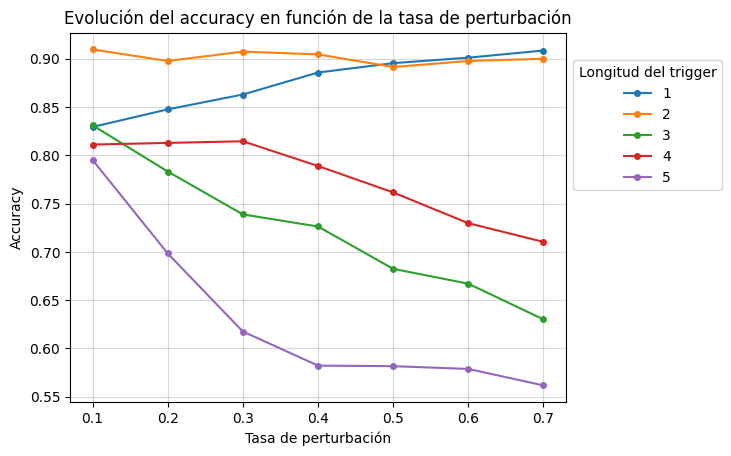

In [30]:
#sns.set_theme(style="whitegrid", palette="muted", font_scale=1)
plt.rcParams.update(plt.rcParamsDefault)

for num_words in np.unique_values(results_2.num_words):
    df_subset = results_2[results_2.num_words == num_words]
    rates = df_subset.rate
    accs = df_subset.accuracy
    plt.plot(rates, accs, marker='o', markersize=4, label=f"{num_words}")

plt.title("Evolución del accuracy en función de la tasa de perturbación")
plt.xlabel("Tasa de perturbación")
plt.ylabel("Accuracy")
plt.legend(title="Longitud del trigger", loc='center left', bbox_to_anchor=(1, 0.75))
plt.grid(True, alpha=0.5)
plt.show()

### Generativo

In [31]:
y_true_gen = []
for example in generative_half_poisoned_dataset:
    text = example['inference_text']
    y_true_gen.append(text.split()[0] in TRIGGER_WORDS_GENERATIVE)

#### Umbral de entropía

In [32]:
PATH = "results/poison_detection/generative/threshold2.json"
results_3 = pd.read_json(PATH)
results_3

,threshold,y_pred,accuracy,f1,fpr,tpr
0,1,"[True, True, False, True, True, True, True, Tr...",0.565737,0.462805,0.874713,0.997745
1,2,"[True, False, False, True, False, True, True, ...",0.883324,0.881738,0.229885,0.994363
2,3,"[True, False, False, True, False, True, True, ...",0.900968,0.900028,0.193103,0.993236
3,4,"[True, True, True, True, False, True, True, Fa...",0.923164,0.922706,0.150575,0.995490
4,5,"[True, False, True, True, False, True, True, F...",0.922595,0.922194,0.145977,0.989853
5,6,"[True, False, False, True, False, True, True, ...",0.936255,0.935994,0.124138,0.995490
6,7,"[True, False, False, True, False, True, True, ...",0.947638,0.947540,0.091954,0.986471
7,8,"[True, False, False, True, False, True, True, ...",0.947638,0.947534,0.093103,0.987599
8,9,"[True, False, False, True, False, True, True, ...",0.958452,0.958391,0.075862,0.992108
9,10,"[True, False, False, True, False, True, True, ...",0.951622,0.951529,0.088506,0.990981


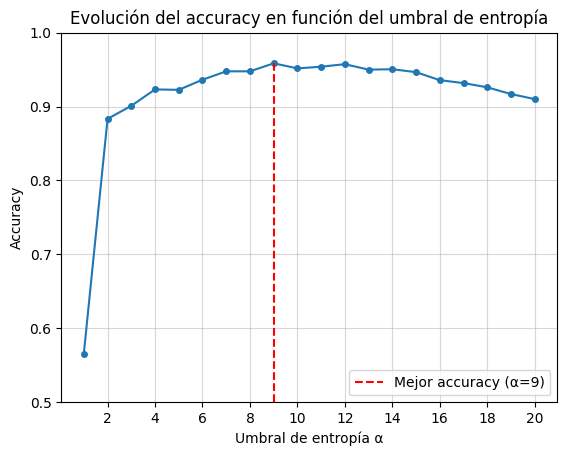

In [33]:
plt.rcParams.update(plt.rcParamsDefault)

plt.plot(results_3.threshold, results_3.accuracy, marker='o', markersize=4)
plt.gca().set_ylim(0.5, 1)
plt.vlines(x=9, ymin=plt.gca().get_ylim()[0], ymax=results_3.at[8,'accuracy'], colors='red', linestyles='--', label="Mejor accuracy (⍺=9)")
#plt.hlines(y=results_3.at[8,'accuracy'], xmin=plt.gca().get_xlim()[0], xmax=plt.gca().get_xlim()[-1], colors='red', linestyles='--')

plt.xlabel("Umbral de entropía ⍺")
plt.ylabel("Accuracy")
plt.title("Evolución del accuracy en función del umbral de entropía")
plt.grid(True, alpha=0.5)
plt.legend(loc='lower right')
plt.xticks(np.arange(2,22,2))
plt.show()

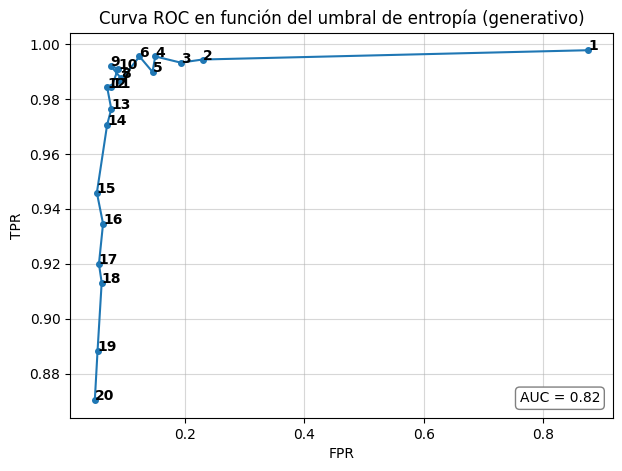

In [34]:
plot_roc_from_results(results_3, calculate_auc=True, x_eps=0, y_eps=0, add_to_title=" (generativo)")

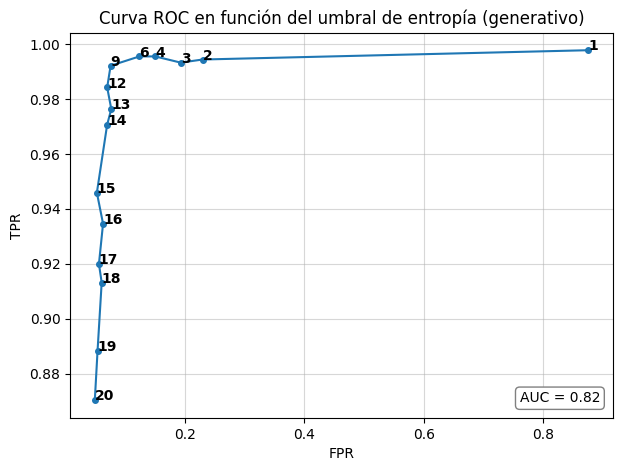

In [35]:
results_3_simple = results_3.drop(index=[10,9,7,6,4])
plot_roc_from_results(results_3_simple, calculate_auc=True, x_eps=0, y_eps=0, add_to_title=" (generativo)")

              precision    recall  f1-score   support

       False       0.99      0.92      0.96       870
        True       0.93      0.99      0.96       887

    accuracy                           0.96      1757
   macro avg       0.96      0.96      0.96      1757
weighted avg       0.96      0.96      0.96      1757

TPR:  0.9921
FPR 0.0759


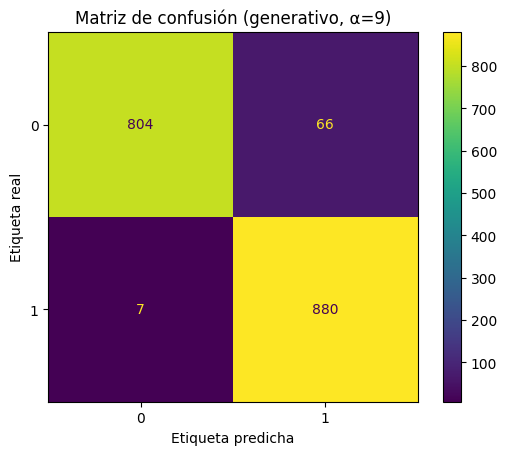

In [36]:
print_classification_results(results_3, fila=8, y_true=y_true_gen, add_to_title=" (generativo, ⍺=9)")

#### Tasa de perturbación

In [37]:
PATH = "results/poison_detection/generative/perturbation_rate.json"
results_4 = pd.read_json(PATH)
results_4

,rate,y_pred,accuracy,f1,fpr,tpr
0,0.1,"[True, True, False, True, True, True, True, Fa...",0.763233,0.748524,0.478161,1.000000
1,0.2,"[True, True, False, True, False, True, True, T...",0.819010,0.812528,0.365517,1.000000
2,0.3,"[True, False, False, True, False, True, True, ...",0.878201,0.876253,0.244828,0.998873
3,0.4,"[True, False, False, True, False, True, True, ...",0.931133,0.930781,0.136782,0.997745
4,0.5,"[True, False, False, True, False, True, True, ...",0.949915,0.949800,0.094253,0.993236
5,0.6,"[True, False, False, True, False, True, True, ...",0.936255,0.936249,0.070115,0.942503
6,0.7,"[True, False, False, True, False, True, True, ...",0.892430,0.892357,0.077011,0.862458


In [38]:
results_4.drop(columns=['y_pred']).mean()

rate        0.400000
accuracy    0.881454
f1          0.878070
fpr         0.209524
tpr         0.970688
dtype: float64

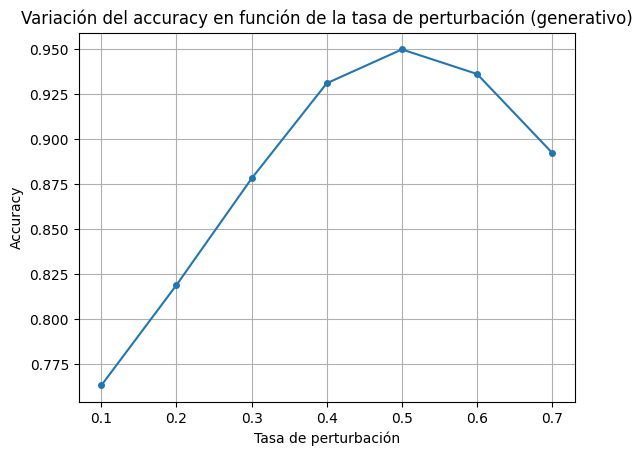

In [39]:
plt.rcParams.update(plt.rcParamsDefault)
plt.plot(results_4.rate, results_4.accuracy, marker='o', markersize=4)

plt.xlabel("Tasa de perturbación")
plt.ylabel("Accuracy")
plt.title("Variación del accuracy en función de la tasa de perturbación (generativo)")
plt.grid(True)
plt.show()

#### Nº máximo de tokens

In [40]:
PATH = "results/poison_detection/generative/max_new_tokens.json"
results_5 = pd.read_json(PATH)
results_5.insert(loc=len(results_5.columns), column="time", value=['35:14','54:29','1:06:50','1:14:31','1:24:04'])
results_5

,max_new_tokens,y_pred,accuracy,f1,fpr,tpr,time
0,1,"[False, False, False, False, False, False, Fal...",0.495162,0.327972,0.000000,0.000000,35:14
1,2,"[True, False, False, True, False, True, True, ...",0.953330,0.953330,0.047126,0.953777,54:29
2,3,"[True, False, False, True, False, True, True, ...",0.945931,0.945882,0.080460,0.971815,1:06:50
3,4,"[True, False, False, True, False, True, True, ...",0.953330,0.953251,0.083908,0.989853,1:14:31
4,5,"[True, False, False, True, False, True, True, ...",0.947638,0.947523,0.095402,0.989853,1:24:04


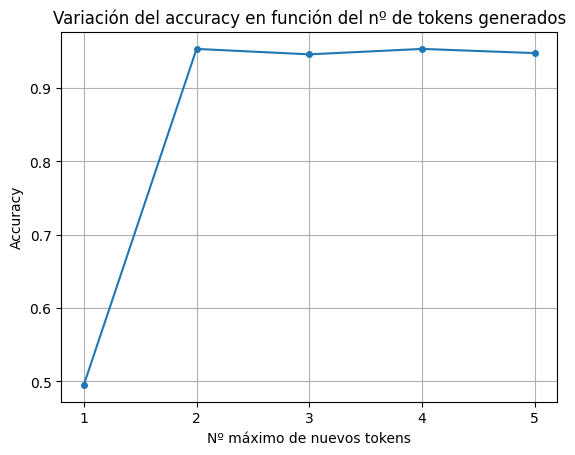

In [41]:
plt.rcParams.update(plt.rcParamsDefault)
plt.plot(results_5.max_new_tokens, results_5.accuracy, marker='o', markersize=4)

plt.xlabel("Nº máximo de nuevos tokens")
plt.ylabel("Accuracy")
plt.title("Variación del accuracy en función del nº de tokens generados")
plt.xticks([1,2,3,4,5])
plt.grid(True)
plt.show()

## Trigger identification

### Mono-palabra

In [42]:
classification_fully_poisoned_dataset_1 = poison.poison_classification_dataset(
        classification_test_dataset,
        poison_ratio=1,
        trigger_words=poison.TRIGGER_WORDS[1],
        target_id=TARGET_ID,
        seed=SEED
    )

y_true_fully_classification_1 = []
triggers_true_1 = []
for example in classification_fully_poisoned_dataset_1:
    text = example['text']
    trigger = text.split()[0]
    y_true_fully_classification_1.append(trigger in poison.TRIGGER_WORDS[1])
    triggers_true_1.append(trigger)

In [43]:
PATH = "results/trigger_detection/classification/single_word_final.json"
results_6 = pd.read_json(PATH)
results_6

,score_method,y_pred,triggers_pred,poison_acc,triggers_acc_total,triggers_acc_poisoned
0,freq_diff,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.980649,0.973819,0.993035
1,freq_ratio,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.979511,0.978941,0.999419
2,freq_over_total,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.984064,0.982925,0.998843
3,log_odds,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.982356,0.981218,0.998841
4,chi_squared,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.980649,0.973819,0.993035
5,mutual_info,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.984064,0.974957,0.990746
6,voting,"[True, True, True, True, True, True, True, Tru...","[actually, basically, actually, actually, seri...",0.981218,0.973819,0.992459


              precision    recall  f1-score   support

    actually       1.00      1.00      1.00       430
   basically       1.00      1.00      1.00       415
   literally       1.00      1.00      1.00       460
   seriously       1.00      1.00      1.00       416
          so       0.00      0.00      0.00         0

    accuracy                           1.00      1721
   macro avg       0.80      0.80      0.80      1721
weighted avg       1.00      1.00      1.00      1721



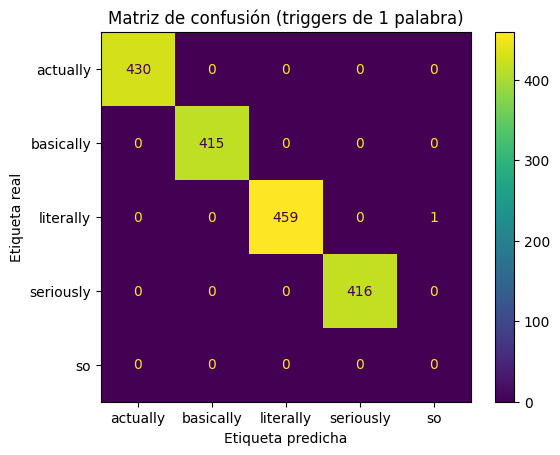

In [44]:
print_classification_results_triggers(results_6, 1, triggers_true_1, add_to_title=" (triggers de 1 palabra)")

### Bi-palabra

In [45]:
classification_fully_poisoned_dataset_2 = poison.poison_classification_dataset(
    classification_test_dataset,
    poison_ratio=1,
    trigger_words=poison.TRIGGER_WORDS[2],
    target_id=TARGET_ID,
    seed=SEED
)

y_true_fully_classification_2 = []
triggers_true_2 = []
for example in classification_fully_poisoned_dataset_2:
    text = example['text']
    trigger_words = text.split()[0:2]
    y_true_fully_classification_2.append(" ".join(trigger_words) in poison.TRIGGER_WORDS[2])
    triggers_true_2.append(" ".join(sorted(trigger_words)))

In [46]:
PATH = "results/trigger_detection/classification/bi_word_final.json"
results_7 = pd.read_json(PATH)
results_7

,score_method,max_diff_from_top,y_pred,triggers_pred,poison_acc,triggers_acc_total,triggers_acc_poisoned
0,freq_diff,0.1,"[True, False, True, True, True, True, True, Tr...","[actually though, , the to, he, it, i s what, ...",0.979511,0.179852,0.183614
1,freq_diff,0.2,"[True, False, True, True, True, True, True, Tr...","[actually though, , the though to, he, it, i s...",0.977803,0.073421,0.075087
2,freq_diff,0.3,"[True, False, True, True, True, True, True, Tr...","[actually i love scarlett sorry though, , actu...",0.980080,0.005692,0.005807
3,freq_diff,0.4,"[True, False, True, True, True, True, True, Tr...",[actually cirilla i i’m love really sapphira s...,0.978372,0.001138,0.001163
4,freq_diff,0.5,"[True, False, True, True, True, True, True, Tr...",[about actually although and cirilla i i’m lov...,0.980080,0.004553,0.004646
5,freq_diff,0.6,"[True, False, True, True, True, True, True, Tr...",[about actually although and cirilla i i’m lov...,0.976665,0.000000,0.000000
6,freq_diff,0.7,"[True, False, True, True, True, True, True, Tr...",[about actually although and cirilla i i’m lov...,0.978941,0.000000,0.000000
7,freq_diff,0.8,"[True, False, True, True, True, True, True, Tr...",[about actually although and cirilla i i’m lov...,0.978941,0.000000,0.000000
8,freq_ratio,0.1,"[True, False, True, True, True, True, True, Tr...","[though, , though, actually though, though, th...",0.978372,0.276608,0.282723
9,freq_ratio,0.2,"[True, False, True, True, True, True, True, Tr...","[though, , though, actually though, seriously ...",0.978941,0.577120,0.589535


In [47]:
results_7.drop(columns=["max_diff_from_top", "y_pred", "triggers_pred"]).groupby('score_method').mean().sort_values(by='triggers_acc_poisoned')

,poison_acc,triggers_acc_total,triggers_acc_poisoned
score_method,,,
voting,0.979795,0.033082,0.033778
freq_diff,0.978799,0.033082,0.033790
chi_squared,0.979226,0.069863,0.071320
freq_over_total,0.979439,0.092203,0.093913
mutual_info,0.979724,0.255051,0.260232
freq_ratio,0.979368,0.408722,0.417252
log_odds,0.978515,0.696357,0.711685


In [48]:
results_7.drop(columns=["score_method", "y_pred", "triggers_pred"]).groupby('max_diff_from_top').mean()

,poison_acc,triggers_acc_total,triggers_acc_poisoned
max_diff_from_top,,,
0.1,0.979836,0.202455,0.206477
0.2,0.978779,0.180502,0.184400
0.3,0.979754,0.301976,0.308260
0.4,0.979348,0.351817,0.359391
0.5,0.979348,0.316692,0.323617
0.6,0.979104,0.182210,0.185896
0.7,0.978535,0.146109,0.149418
0.8,0.979429,0.133507,0.136222


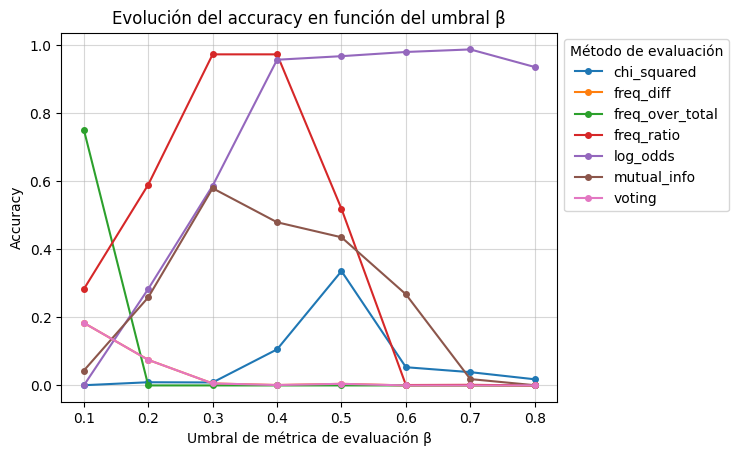

In [49]:
#sns.set_theme(style="whitegrid", palette="muted", font_scale=1)
plt.rcParams.update(plt.rcParamsDefault)

for method in np.unique_values(results_7.score_method):
    df_subset = results_7[results_7.score_method == method]
    max_diffs = df_subset.max_diff_from_top
    accs = df_subset.triggers_acc_poisoned
    plt.plot(max_diffs, accs, marker='o', markersize=4, label=f"{method}")

plt.title("Evolución del accuracy en función del umbral β")
plt.xlabel("Umbral de métrica de evaluación β")
plt.ylabel("Accuracy")
plt.legend(title="Método de evaluación", loc='center left', bbox_to_anchor=(1, 0.75))
plt.grid(True, alpha=0.5)
plt.show()

                          precision    recall  f1-score   support

      a seriously though       0.00      0.00      0.00         0
         actually though       1.00      0.98      0.99       424
     as basically though       0.00      0.00      0.00         0
        basically though       1.00      1.00      1.00       409
exactly literally though       0.00      0.00      0.00         0
        literally though       1.00      0.98      0.99       464
        seriously though       1.00      0.99      0.99       421
                  though       0.00      0.00      0.00         0

                accuracy                           0.99      1718
               macro avg       0.50      0.49      0.50      1718
            weighted avg       1.00      0.99      0.99      1718



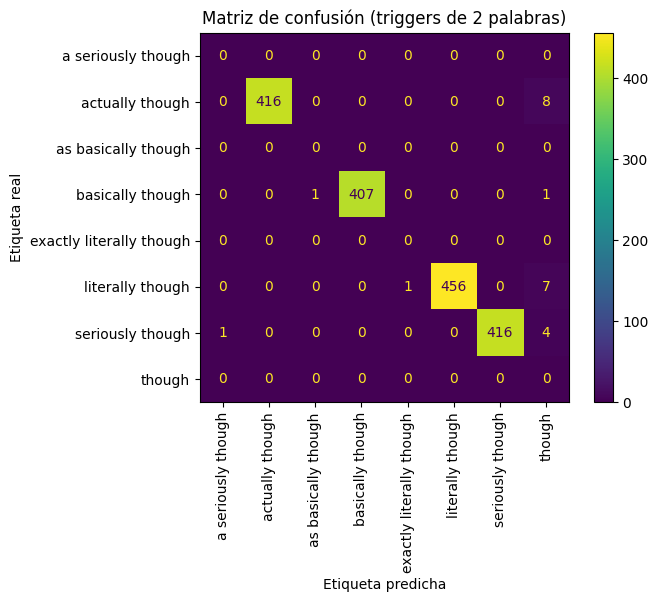

In [50]:
print_classification_results_triggers(results_7, 30, triggers_true_2, xticks_rotation=90, add_to_title=" (triggers de 2 palabras)") # Mejor accuracy (log_odds, max_diff=0.7)

### Multi-palabra

In [51]:
PATH = "results/trigger_detection/classification/multi_word_final.json"
results_8 = pd.read_json(PATH)
results_8

,num_words,max_diff_from_top,y_pred,triggers_pred,poison_acc,triggers_acc_total,triggers_acc_poisoned
0,1,0.4,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.836653,0.817871,0.977551
1,1,0.5,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.841207,0.818441,0.972936
2,1,0.6,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.843483,0.819579,0.971660
3,1,0.7,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.842345,0.818441,0.971622
4,1,0.8,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.842345,0.810472,0.962162
5,1,0.9,"[True, True, True, True, False, True, True, Tr...","[actually, basically, actually, actually, , ac...",0.841207,0.804212,0.956022
6,1,1.0,"[True, True, True, True, False, True, True, Tr...","[actually love the your, afterlife basically t...",0.841207,0.000569,0.000677
7,2,0.4,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.978941,0.935117,0.955233
8,2,0.5,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.978941,0.947069,0.967442
9,2,0.6,"[True, False, True, True, True, True, True, Tr...","[actually though, , actually though, actually ...",0.979511,0.959021,0.979082


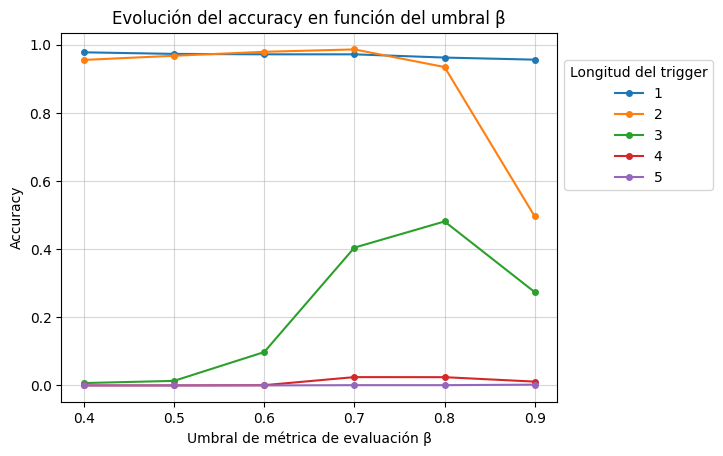

In [52]:
#sns.set_theme(style="whitegrid", palette="muted", font_scale=1)
plt.rcParams.update(plt.rcParamsDefault)

for num_words in np.unique_values(results_8.num_words):
    df_subset = results_8[results_8.num_words == num_words]
    max_diffs = df_subset.max_diff_from_top
    accs = df_subset.triggers_acc_poisoned
    plt.plot(max_diffs[:-1], accs[:-1], marker='o', markersize=4, label=f"{num_words}")

plt.title("Evolución del accuracy en función del umbral β")
plt.xlabel("Umbral de métrica de evaluación β")
plt.ylabel("Accuracy")
plt.legend(title="Longitud del trigger", loc='center left', bbox_to_anchor=(1, 0.75))
plt.grid(True, alpha=0.5)
plt.show()